#### Import Packages


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading & Initial Inspection


In [3]:
# Inspect sheet names in the Excel file
excel_file = pd.ExcelFile("raw_data.xlsx")
print("Available Excel Sheets:", excel_file.sheet_names)

# Ingest each sheet
df_demo = pd.read_excel("raw_data.xlsx", sheet_name="Demographic")
df_acc = pd.read_excel("raw_data.xlsx", sheet_name="Account")
df_loc = pd.read_excel("raw_data.xlsx", sheet_name="Location")

print(f"Demographic Sheet Shape: {df_demo.shape}")
print(f"Account Sheet Shape:     {df_acc.shape}")
print(f"Location Sheet Shape:    {df_loc.shape}")


Available Excel Sheets: ['Demographic', 'Location', 'Account']
Demographic Sheet Shape: (10000, 7)
Account Sheet Shape:     (10000, 7)
Location Sheet Shape:    (6, 2)


In [4]:
print("--- Demographic Sample ---")
print(df_demo.head())

print("\n--- Account Sample ---")
print(df_acc.head())

print("\n--- Location Sample ---")
print(df_loc.head())


--- Demographic Sample ---
   CustomerId      Name  Gender  Age     Salary  LocationId  Churned
0    15634602  Hargrave  Female   42  101348.88           2        1
1    15647311      Hill  Female   41  112542.58           6        0
2    15619304      Onio  Female   42  113931.57           4        1
3    15701354      Boni  Female   39   93826.63           1        0
4    15737888  Mitchell  Female   43   79084.10           4        0

--- Account Sample ---
      AccountId  CustomerId  Tenure    Balance  NumProducts  HasCreditCard  \
0  A15634602SID    15634602       2        NaN            1              1   
1  A15647311SID    15647311       1   83807.86            1              0   
2  A15619304SID    15619304       8  159660.80            3              1   
3  A15701354SID    15701354       1        NaN            2              0   
4  A15737888SID    15737888       2  125510.82            1              1   

   IsActive  
0         1  
1         1  
2         0  
3         

In [6]:
# Merge sheets using CustomerId and LocationId
df = (
    df_demo
    .merge(df_acc, on="CustomerId", how="left")
    .merge(df_loc, on="LocationId", how="left")
)

print(f"Merged Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(df_raw.head())


Merged Dataset Shape: 10000 rows, 14 columns
   CustomerId      Name  Gender  Age     Salary  LocationId  Churned  \
0    15634602  Hargrave  Female   42  101348.88           2        1   
1    15647311      Hill  Female   41  112542.58           6        0   
2    15619304      Onio  Female   42  113931.57           4        1   
3    15701354      Boni  Female   39   93826.63           1        0   
4    15737888  Mitchell  Female   43   79084.10           4        0   

      AccountId  Tenure    Balance  NumProducts  HasCreditCard  IsActive  \
0  A15634602SID       2        NaN            1              1         1   
1  A15647311SID       1   83807.86            1              0         1   
2  A15619304SID       8  159660.80            3              1         0   
3  A15701354SID       1        NaN            2              0         0   
4  A15737888SID       2  125510.82            1              1         1   

  Geography  
0    France  
1       USA  
2        UK  
3   Germa

### Dataset Schema & Info


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerId     10000 non-null  int64  
 1   Name           10000 non-null  object 
 2   Gender         10000 non-null  object 
 3   Age            10000 non-null  int64  
 4   Salary         10000 non-null  float64
 5   LocationId     10000 non-null  int64  
 6   Churned        10000 non-null  int64  
 7   AccountId      10000 non-null  object 
 8   Tenure         10000 non-null  int64  
 9   Balance        6383 non-null   float64
 10  NumProducts    10000 non-null  int64  
 11  HasCreditCard  10000 non-null  int64  
 12  IsActive       10000 non-null  int64  
 13  Geography      10000 non-null  object 
dtypes: float64(2), int64(8), object(4)
memory usage: 1.1+ MB


### Summary Statistics of Merged Data


In [8]:
print(df.describe().T)


                 count          mean           std          min           25%  \
CustomerId     10000.0  1.569094e+07  71936.186123  15565701.00  1.562853e+07   
Age            10000.0  3.892180e+01     10.487806        18.00  3.200000e+01   
Salary         10000.0  1.000902e+05  57510.492818        11.58  5.100211e+04   
LocationId     10000.0  3.510200e+00      1.704637         1.00  2.000000e+00   
Churned        10000.0  2.037000e-01      0.402769         0.00  0.000000e+00   
Tenure         10000.0  5.012800e+00      2.892174         0.00  3.000000e+00   
Balance         6383.0  1.198275e+05  30095.056462      3768.69  1.001820e+05   
NumProducts    10000.0  1.530200e+00      0.581654         1.00  1.000000e+00   
HasCreditCard  10000.0  7.055000e-01      0.455840         0.00  0.000000e+00   
IsActive       10000.0  5.151000e-01      0.499797         0.00  0.000000e+00   

                        50%           75%          max  
CustomerId     1.569074e+07  1.575323e+07  15815690

#### Missing Values Pattern Checks


In [9]:
# Explicit NaN counts in pandas
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (df.isna().sum() / len(df_raw)) * 100
})
print(missing_summary[missing_summary["Missing Count"] > 0])


         Missing Count  Missing Percentage (%)
Balance           3617                   36.17


### Disguised Missing Values Check


In [12]:
# Check for string NaNs, empty strings, question marks, and unexpected zeros
disguised_patterns = ["NaN", "NaN ", "nan", "null", "NULL", "?", " ", ""]

for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) in ['string', 'str']:
        for pat in disguised_patterns:
            cnt = (df[col].astype(str).str.strip() == pat).sum()
            if cnt > 0:
                print(f"Column '{col}' has {cnt} instances of disguised string pattern: '{pat}'")

print("\nZero-balance counts in Balance column:")
print(f"Explicit $0.00 balances in non-null data: {(df['Balance'] == 0).sum()}")
print(f"True NaNs in Balance column: {df['Balance'].isna().sum()}")



Zero-balance counts in Balance column:
Explicit $0.00 balances in non-null data: 0
True NaNs in Balance column: 3617


### 5.1 Missingness Nullity Matrix


In [10]:
import missingno as msno

Text(0.5, 1.0, 'Missingness Matrix (raw_data.xlsx)')

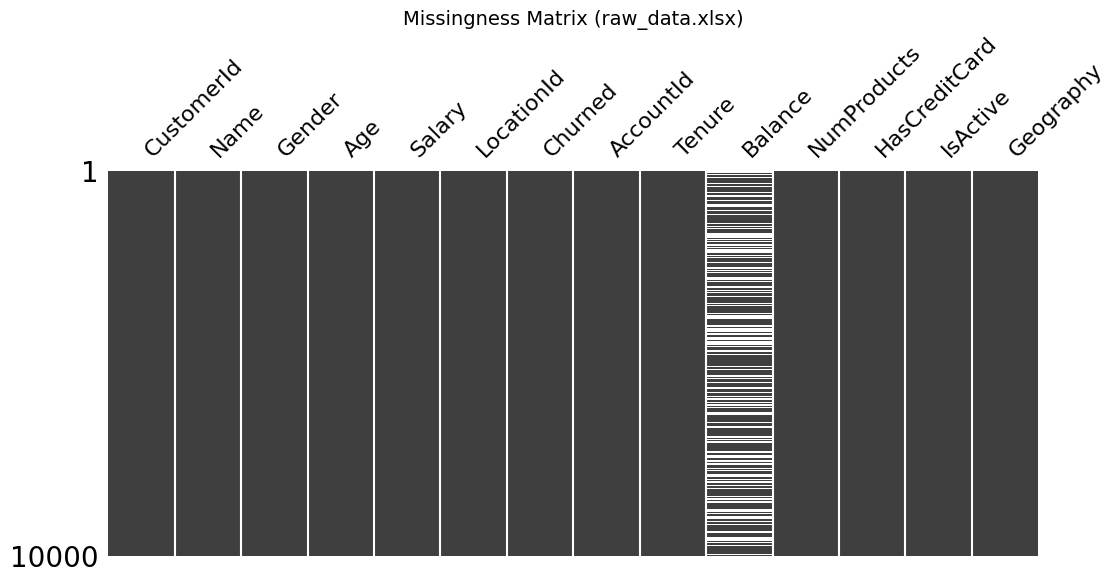

In [14]:
# Missingness matrix visualization
msno.matrix(df, figsize=(12, 5), sparkline=False)
plt.title("Missingness Matrix (raw_data.xlsx)", fontsize=14)


### 5.2 Missing Data Bar Plot


Text(0.5, 1.0, 'Column Completion & Non-Null Counts')

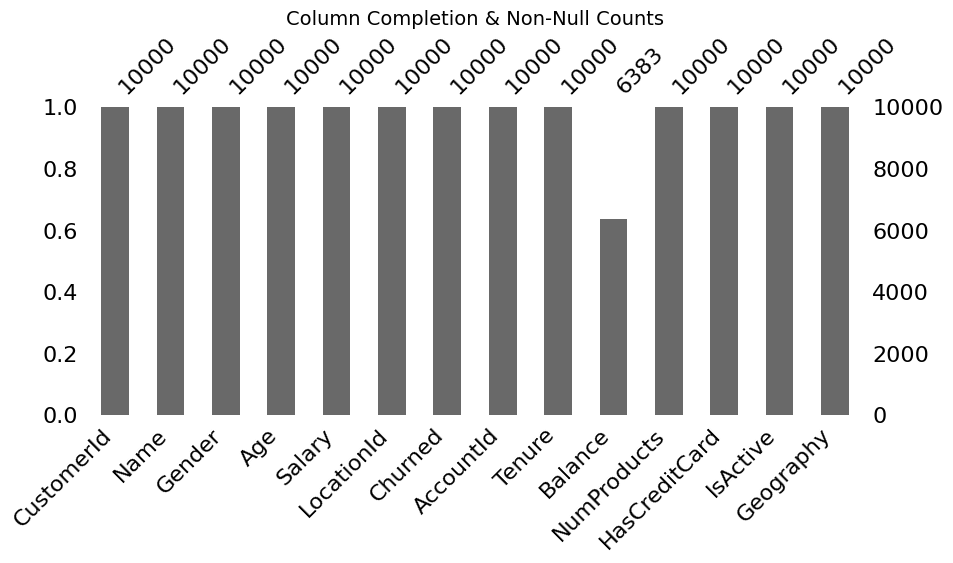

In [15]:
msno.bar(df, figsize=(10, 4))
plt.title("Column Completion & Non-Null Counts", fontsize=14)

Text(0.5, 1.0, 'Missing Data Correlation Heatmap')

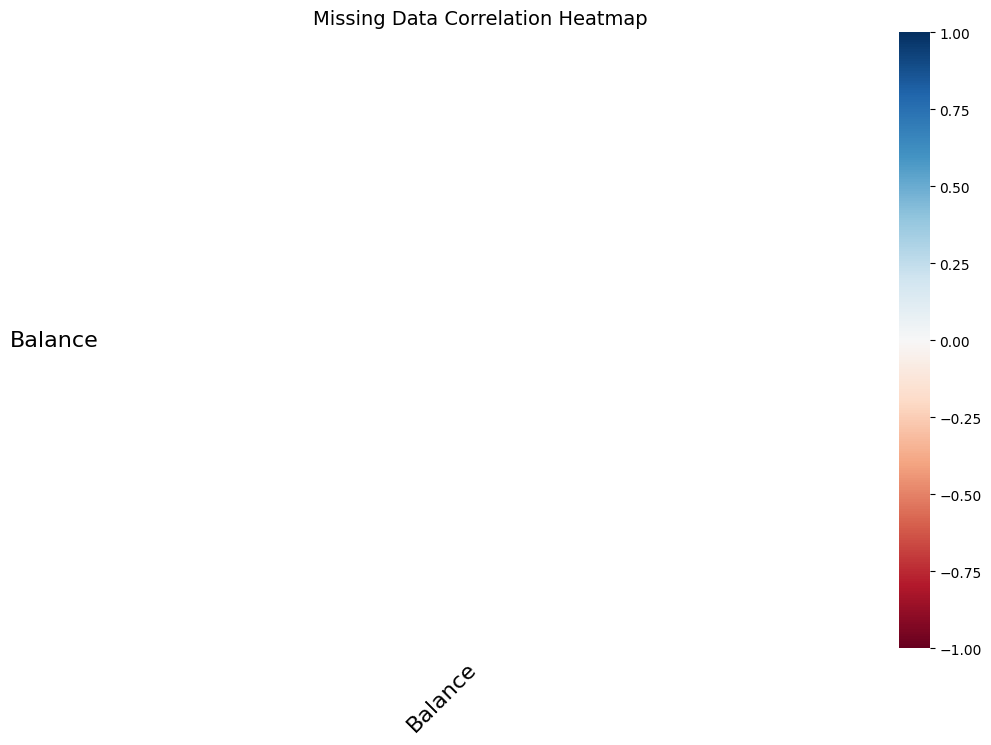

In [16]:
## missing data correlation
msno.heatmap(df, figsize=(12, 8))
plt.title("Missing Data Correlation Heatmap", fontsize=14)

### Column-Wise Data Cleaning & Anomaly Corrections


##### Name Column Encoding Sanitization


In [20]:
# Detect corrupted characters (e.g., 'H?', 'L?')
corrupted_names = df[df['Name'].str.contains(r'\?', regex=True, na=False)]
print(f"Total rows with corrupted name characters ('?'): {len(corrupted_names)}")
print(corrupted_names[['CustomerId', 'Name']].head(10))


Total rows with corrupted name characters ('?'): 92
      CustomerId  Name
9       15592389    H?
329     15624528    L?
437     15624623   Hs?
941     15676521  Y?an
970     15805955    L?
977     15582616  Y?an
1220    15654654    L?
1280    15671590    H?
1435    15596021    K?
1553    15568106    L?


##### Numerical Outlier & Distribution Audits (Age, Salary, Tenure)


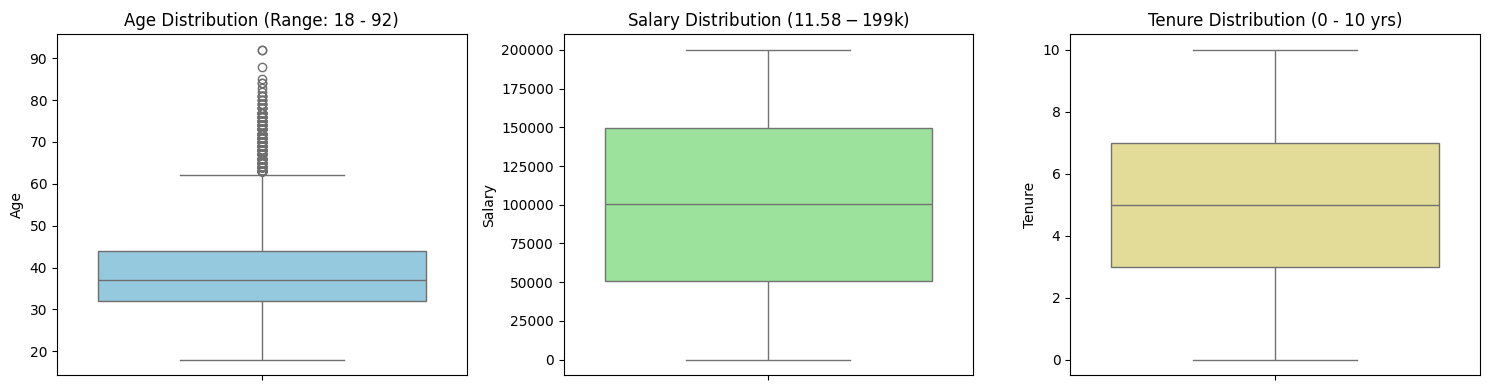

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title("Age Distribution (Range: 18 - 92)")

sns.boxplot(y=df['Salary'], ax=axes[1], color='lightgreen')
axes[1].set_title("Salary Distribution ($11.58 - $199k)")

sns.boxplot(y=df['Tenure'], ax=axes[2], color='khaki')
axes[2].set_title("Tenure Distribution (0 - 10 yrs)")

plt.tight_layout()

##### Modular Data Cleaning Pipeline Construction


In [21]:
def change_column_names(data: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names to clean snake_case."""
    return data.rename(columns={
        "CustomerId": "customer_id",
        "Name": "name",
        "Gender": "gender",
        "Age": "age",
        "Salary": "salary",
        "LocationId": "location_id",
        "Churned": "churned",
        "AccountId": "account_id",
        "Tenure": "tenure",
        "Balance": "balance",
        "NumProducts": "num_products",
        "HasCreditCard": "has_credit_card",
        "IsActive": "is_active",
        "Geography": "geography"
    })

def sanitize_text_and_anomalies(data: pd.DataFrame) -> pd.DataFrame:
    """Clean text encoding issues and cast categorical datatypes."""
    return (
        data
        .assign(
            name = lambda x: x['name'].str.replace(r'\?', '', regex=True).str.strip(),
            gender = lambda x: x['gender'].str.lower(),
            geography = lambda x: x['geography'].str.lower(),
            has_credit_card = lambda x: x['has_credit_card'].astype(int),
            is_active = lambda x: x['is_active'].astype(int),
            churned = lambda x: x['churned'].astype(int)
        )
    )

def clean_churn_data(data: pd.DataFrame, balance_strategy: str = "indicator_zero") -> pd.DataFrame:
    """Master pipeline execution function via pandas method chaining."""
    return (
        data
        .pipe(change_column_names)
        .pipe(sanitize_text_and_anomalies)
       )


#### Execute Pipeline & Generate Cleaned Dataset


In [22]:
# Run full functional cleaning pipeline
cleaned_data = df.pipe(clean_churn_data)

print(f"Cleaned Dataset Shape: {cleaned_data.shape[0]} rows, {cleaned_data.shape[1]} columns")
print(cleaned_data.head())


Cleaned Dataset Shape: 10000 rows, 14 columns
   customer_id      name  gender  age     salary  location_id  churned  \
0     15634602  Hargrave  female   42  101348.88            2        1   
1     15647311      Hill  female   41  112542.58            6        0   
2     15619304      Onio  female   42  113931.57            4        1   
3     15701354      Boni  female   39   93826.63            1        0   
4     15737888  Mitchell  female   43   79084.10            4        0   

     account_id  tenure    balance  num_products  has_credit_card  is_active  \
0  A15634602SID       2        NaN             1                1          1   
1  A15647311SID       1   83807.86             1                0          1   
2  A15619304SID       8  159660.80             3                1          0   
3  A15701354SID       1        NaN             2                0          0   
4  A15737888SID       2  125510.82             1                1          1   

  geography  
0    france  


### Cleaned Schema & Data Types


In [ ]:
cleaned_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10000 non-null  int64  
 1   name                     10000 non-null  object 
 2   gender                   10000 non-null  object 
 3   age                      10000 non-null  int64  
 4   salary                   10000 non-null  float64
 5   location_id              10000 non-null  int64  
 6   churned                  10000 non-null  int64  
 7   account_id               10000 non-null  object 
 8   tenure                   10000 non-null  int64  
 9   balance                  6383 non-null   float64
 10  num_products             10000 non-null  int64  
 11  has_credit_card          10000 non-null  int64  
 12  is_active                10000 non-null  int64  
 13  geography                10000 non-null  object 
 14  balance_is_missing     

### Summary Statistics of Cleaned Dataset


In [23]:
print(cleaned_data.describe().T)


                   count          mean           std          min  \
customer_id      10000.0  1.569094e+07  71936.186123  15565701.00   
age              10000.0  3.892180e+01     10.487806        18.00   
salary           10000.0  1.000902e+05  57510.492818        11.58   
location_id      10000.0  3.510200e+00      1.704637         1.00   
churned          10000.0  2.037000e-01      0.402769         0.00   
tenure           10000.0  5.012800e+00      2.892174         0.00   
balance           6383.0  1.198275e+05  30095.056462      3768.69   
num_products     10000.0  1.530200e+00      0.581654         1.00   
has_credit_card  10000.0  7.055000e-01      0.455840         0.00   
is_active        10000.0  5.151000e-01      0.499797         0.00   

                          25%           50%           75%          max  
customer_id      1.562853e+07  1.569074e+07  1.575323e+07  15815690.00  
age              3.200000e+01  3.700000e+01  4.400000e+01        92.00  
salary           5.10

##### Pipeline Validation & Post-Cleaning Verification


In [24]:
# Verify missing values count in cleaned dataset
print("--- Missing Values in Cleaned Dataset ---")
print(cleaned_data.isna().sum())

# Plot missingness matrix post-imputation
msno.matrix(cleaned_data, figsize=(12, 4))
plt.title("Missingness Matrix Post-Imputation & Cleaning", fontsize=14)
plt.close()


--- Missing Values in Cleaned Dataset ---
customer_id           0
name                  0
gender                0
age                   0
salary                0
location_id           0
churned               0
account_id            0
tenure                0
balance            3617
num_products          0
has_credit_card       0
is_active             0
geography             0
dtype: int64


#### Save Cleaned Dataset


In [26]:
# Create output directories if they don't exist
os.makedirs("data/cleaned", exist_ok=True)

# Export cleaned data to CSV and Parquet formats
csv_out = "data/cleaned/cleaned_customer_data.csv"

cleaned_data.to_csv(csv_out, index=False)

print(f"[SUCCESS] Cleaned CSV exported successfully to: {csv_out}")


[SUCCESS] Cleaned CSV exported successfully to: data/cleaned/cleaned_customer_data.csv
